In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('products_asos.csv', on_bad_lines='skip', engine='python')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
print(f"Data Loaded :{len(df)}rows")
df.head()

Data Loaded :18378rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [28]:
df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unknown"
  return "Unknown"

df['brand_raw'] = df['description'].apply(get_brand)

In [29]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [30]:
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop',

}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])
brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))


Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [31]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  out_of_stock_count = size_str.count('Out of stock')
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))
df_clean['Stockout_Count'] = [x[0]for x in metrics]
df_clean['Stockout_Rate'] = [x[1]for x in metrics]

df_clean['Lost_Revenue'] = df_clean['price']* df_clean['Stockout_Count']
cols = ['Brand', 'name', 'price', 'size', 'Stockout_Count', 'Lost_Revenue']
print(df_clean.sort_values(by='Lost_Revenue', ascending=False)[cols].head(5))







         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

                                                    size  Stockout_Count  \
2941   UK 6 - £219.00 - Out of stock,UK 8 - £219.00 -...               9   
21948  UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...               7   
2715   UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...               7   
15584  UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...               6   
29838  W24 L30 - Out of stock,W24 L32 - Out of stock,...              27   

       Lost_Revenue  
2941         1971.0  
21948        1820.0  
2715         1540.0 

/tmp/ipykernel_610/2704643750.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


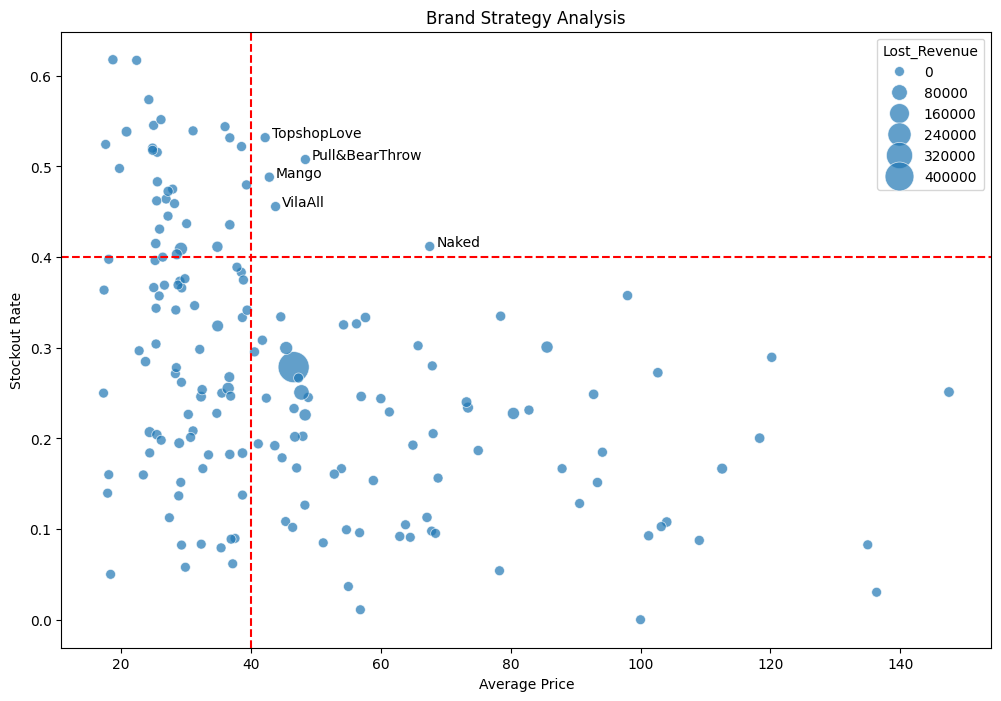

In [32]:
brand_strategy= df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',
    'Lost_Revenue': 'sum',
    'name' : 'count'
}).reset_index()
brand_strategy = brand_strategy[brand_strategy['name']>10]
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=brand_strategy,
    x = 'price',
    y = 'Stockout_Rate',
    size='Lost_Revenue',
    sizes = (50,500),
    alpha = 0.7,
    palette ='viridis'
)

winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)

]
for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['Brand']

    )
plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')
plt.show()

In [33]:
df_clean.to_csv("asos_clean.csv", index=False)